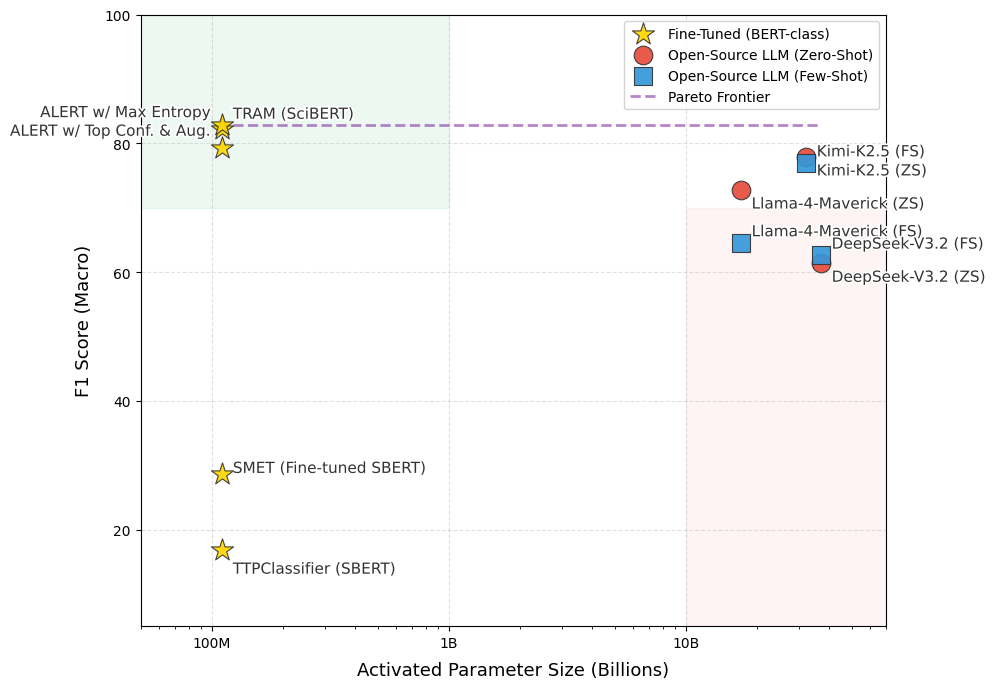

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
from matplotlib.ticker import FuncFormatter

# ──────────────────────────────────────────────────────────────
# Data (open-source models only, closed-source excluded)
# ──────────────────────────────────────────────────────────────
# Parameter sizes in billions (using activated/effective params for MoE models)
# For BERT-class models ~110M = 0.11B

models = {
    # Fine-tuned models (BERT-class, ~110M params)
    "ALERT w/ Max Entropy":          {"params_B": 0.11, "f1": 82.17, "category": "fine-tuned", "marker": "*",  "color": "#FFD700"},
    "ALERT w/ Top Conf. & Aug.":     {"params_B": 0.11, "f1": 79.28, "category": "fine-tuned", "marker": "*",  "color": "#FFD700"},
    "TRAM (SciBERT)":                {"params_B": 0.11, "f1": 82.78, "category": "fine-tuned", "marker": "D",  "color": "#2ECC71"},
    "SMET (Fine-tuned SBERT)":       {"params_B": 0.11, "f1": 28.64, "category": "fine-tuned", "marker": "D",  "color": "#2ECC71"},
    "TTPClassifier (SBERT)":         {"params_B": 0.11, "f1": 16.87, "category": "fine-tuned", "marker": "D",  "color": "#2ECC71"},

    # Open-source LLMs — Zero-shot
    "Llama-4-Maverick (ZS)":         {"params_B": 17,   "f1": 72.72, "category": "open-zs",   "marker": "o",  "color": "#E74C3C"},
    "DeepSeek-V3.2 (ZS)":            {"params_B": 37,   "f1": 61.35, "category": "open-zs",   "marker": "o",  "color": "#E74C3C"},
    "Kimi-K2.5 (ZS)":                {"params_B": 32,   "f1": 77.86, "category": "open-zs",   "marker": "o",  "color": "#E74C3C"},

    # Open-source LLMs — Few-shot (10)
    "Llama-4-Maverick (FS)":         {"params_B": 17,   "f1": 64.53, "category": "open-fs",   "marker": "s",  "color": "#3498DB"},
    "DeepSeek-V3.2 (FS)":            {"params_B": 37,   "f1": 62.61, "category": "open-fs",   "marker": "s",  "color": "#3498DB"},
    "Kimi-K2.5 (FS)":                {"params_B": 32,   "f1": 76.95, "category": "open-fs",   "marker": "s",  "color": "#3498DB"},
}

# ──────────────────────────────────────────────────────────────
# Single plot: F1 Score (Macro)
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
# fig.patch.set_facecolor("#F7F7F7")
# ax.set_facecolor("#FAFAFA")
ax.grid(True, linestyle="--", alpha=0.35, color="#AAAAAA")

metric = "f1"
metric_label = "F1 Score (Macro)"

# ── Collect data for each category ──
category_data = {}
for name, info in models.items():
    cat = info["category"]
    if cat not in category_data:
        category_data[cat] = {"params": [], "metric_vals": [], "names": [], "marker": info["marker"], "color": info["color"]}
    category_data[cat]["params"].append(info["params_B"])
    category_data[cat]["metric_vals"].append(info[metric])
    category_data[cat]["names"].append(name)

cat_legend = {
    "fine-tuned": "Fine-Tuned (BERT-class)",
    "open-zs":    "Open-Source LLM (Zero-Shot)",
    "open-fs":    "Open-Source LLM (Few-Shot)",
}

# ── Scatter each category ──
for cat, data in category_data.items():
    xs = np.array(data["params"])
    ys = np.array(data["metric_vals"])
    size = 280 if data["marker"] == "*" else 180
    ax.scatter(
        xs, ys,
        marker=data["marker"],
        s=size,
        c=data["color"],
        edgecolors="#333333",
        linewidths=0.8,
        label=cat_legend.get(cat, cat),
        zorder=5,
        alpha=0.92,
    )

# ── Annotate every point ──
for name, info in models.items():
    x = info["params_B"]
    y = info[metric]

    if "ALERT" in name:
        offset = (-8, 12)
        ha = "right"
    elif "TRAM" in name:
        offset = (8, 8)
        ha = "left"
    elif "TTP" in name:
        offset = (8, -14)
        ha = "left"
    elif "SMET" in name:
        offset = (8, 4)
        ha = "left"
    elif "ZS" in name:
        offset = (8, -10)
        ha = "left"
    else:
        offset = (8, 8)
        ha = "left"

    ax.annotate(
        name,
        xy=(x, y),
        xytext=offset,
        textcoords="offset points",
        fontsize=11,
        ha=ha,
        va="center",
        color="#333333",
        path_effects=[withStroke(linewidth=2.5, foreground="white")],
    )

# ── Compute and draw Pareto frontier ──
all_params  = np.array([info["params_B"] for info in models.values()])
all_metrics = np.array([info[metric]     for info in models.values()])

sorted_idx = np.argsort(all_params)
sp = all_params[sorted_idx]
sm = all_metrics[sorted_idx]

pareto_x, pareto_y = [sp[0]], [sm[0]]
best_metric = sm[0]
for i in range(1, len(sp)):
    if sm[i] > best_metric:
        best_metric = sm[i]
        pareto_x.append(sp[i])
        pareto_y.append(sm[i])
if pareto_x[-1] != sp[-1]:
    pareto_x.append(sp[-1])
    pareto_y.append(best_metric)

ax.step(pareto_x, pareto_y, where="post", color="#8E44AD", linewidth=2, linestyle="--", alpha=0.65, label="Pareto Frontier", zorder=4)

# ── Shade zones ──
ylim_lo, ylim_hi = 5, 100
xlim_lo, xlim_hi = 0.05, 70

# Top-Left: Golden Zone
ax.axvspan(xlim_lo, 1.0, ymin=(70 - ylim_lo) / (ylim_hi - ylim_lo), ymax=1.0,
           alpha=0.08, color="#27AE60", zorder=0)
# ax.text(0.13, 94, 'Golden Zone',
#         fontsize=11, fontweight="bold", color="#1B7A3D",
#         style="italic", path_effects=[withStroke(linewidth=2, foreground="white")], zorder=10)
# ax.text(0.13, 90.5, 'High Performance, Small Model',
#         fontsize=8.5, color="#1B7A3D",
#         path_effects=[withStroke(linewidth=2, foreground="white")], zorder=10)

# Bottom-Right: Zero-Shot LLMs
ax.axvspan(10, xlim_hi, ymin=0, ymax=(70 - ylim_lo) / (ylim_hi - ylim_lo),
           alpha=0.06, color="#E74C3C", zorder=0)
# ax.text(30, 18, 'Zero-Shot LLMs',
#         fontsize=11, fontweight="bold", color="#C0392B",
#         style="italic", path_effects=[withStroke(linewidth=2, foreground="white")], zorder=10)
# ax.text(30, 14, 'Lower Performance, Massive Cost/Latency',
#         fontsize=8.5, color="#C0392B",
#         path_effects=[withStroke(linewidth=2, foreground="white")], zorder=10)

# ── Axis formatting ──
ax.set_xscale("log")
ax.set_xlim(xlim_lo, xlim_hi)
ax.set_ylim(ylim_lo, ylim_hi)
ax.set_xlabel("Activated Parameter Size (Billions)", fontsize=13, labelpad=8)
ax.set_ylabel(metric_label, fontsize=13, labelpad=8)
# ax.set_title("ALERT: Pareto Frontier of Efficiency\nParameter Size vs F1 Score (Open-Source Only)",
#              fontsize=15, fontweight="bold", pad=14)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}B" if v >= 1 else f"{v*1000:.0f}M"))
ax.legend(loc="upper right", fontsize=10, framealpha=0.85)


plt.tight_layout()
plt.savefig("../vis/pareto_frontier_efficiency.png", bbox_inches="tight", dpi=300)
plt.show()